Каждый из нас писал в школе и университете изложения, сочинения, рефераты. А значит, в каждом из нас живет великий русский писатель.
В этой работе будем раскрывать свои таланты, находить себя в ряду таких гениев, как Пушкин, Гоголь, Грибоедов

В этой работе
- скачаем корпус текстов 20-ми русских писателей. Каждый текст разобьем на обучающую и тестовую выборки.
- разработаем и обучим нейронную сеть определяющию авторство фрагментов текста (по тестовой выборке)
- скачаем СВОЕ сочинение (или чье-нибудь - есть в архиве). Сделаем из него проверочную выборку
- предложим нейронке предсказать автора сочинения (по проверочной выборке)
- объявим себя великим писателем, например, Гончаровым

Ссылка на архив: https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip

В работе рекомендуется пользоваться материалами из ноутбука практического занятия "Рекуррентные и одномерные сверточные нейронные сети". Допускается выбрать лучший вариант нейронки и адаптировать ее структуру, параметры обучения и формирования датасетов под свои *нужды*

In [1]:
import os
import zipfile
import urllib.request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding, Input
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical


In [2]:
DATA_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l7/20writers.zip'
ARCHIVE_FILE = '20writers.zip'
DATA_DIR = 'writers'


def load_archive(url=DATA_URL, archive_name=ARCHIVE_FILE):
    """Скачивает архив, если его ещё нет в рабочей папке."""
    if not os.path.exists(archive_name):
        urllib.request.urlretrieve(url, archive_name)


def unpack_archive(archive_name=ARCHIVE_FILE, target_dir=DATA_DIR):
    """Распаковывает корпус текстов в указанную папку."""
    with zipfile.ZipFile(archive_name, 'r') as archive:
        archive.extractall(target_dir)


load_archive()
unpack_archive()


In [3]:
fragment_len = 1000    # длина текстового фрагмента
step = 100             # сдвиг окна при нарезке


def collect_text_fragments(folder, part_size=fragment_len, stride=step):
    """Читает тексты писателей и нарезает их на перекрывающиеся фрагменты."""
    fragments = []
    targets = []
    class_names = []

    for filename in os.listdir(folder):
        full_path = os.path.join(folder, filename)

        if not os.path.isfile(full_path):
            continue

        writer_name = os.path.splitext(filename)[0]

        if writer_name not in class_names:
            class_names.append(writer_name)

        writer_id = class_names.index(writer_name)

        with open(full_path, encoding='utf-8') as file:
            text = file.read()

        for start in range(0, len(text) - part_size, stride):
            fragments.append(text[start:start + part_size])
            targets.append(writer_id)

    return fragments, targets, class_names


texts, labels, author_names = collect_text_fragments(DATA_DIR)

for name in author_names:
    print(f'Автор: {name}')

print('Всего фрагментов:', len(texts))


Автор: Тургенев
Автор: Лесков
Автор: Гоголь
Автор: Катаев
Автор: Пушкин
Автор: Шолохов
Автор: Каверин
Автор: Толстой
Автор: Горький
Автор: Достоевский
Автор: Грибоедов
Автор: Гончаров
Автор: Пастернак
Автор: Булгаков
Автор: Лермонтов
Автор: Беляев
Автор: Васильев
Автор: Чехов
Автор: Куприн
Автор: Носов
Всего фрагментов: 561896


In [4]:
max_words = 20000
max_len = 200


def prepare_sequences(raw_texts, raw_labels, vocab_size=max_words, seq_len=max_len):
    """Преобразует тексты в числовые последовательности и кодирует метки классов."""
    text_tokenizer = Tokenizer(num_words=vocab_size)
    text_tokenizer.fit_on_texts(raw_texts)

    token_sequences = text_tokenizer.texts_to_sequences(raw_texts)
    features = pad_sequences(token_sequences, maxlen=seq_len)

    targets = to_categorical(raw_labels, num_classes=len(author_names))

    return features, targets, text_tokenizer


X, y, tokenizer = prepare_sequences(texts, labels)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)


In [6]:
def create_lstm_model(vocab_size, seq_len, classes_count):
    """Создаёт LSTM-модель для определения автора текстового фрагмента."""
    net = Sequential(name='writer_lstm_classifier')
    net.add(Input(shape=(seq_len,)))
    net.add(Embedding(input_dim=vocab_size, output_dim=128))
    net.add(LSTM(128))
    net.add(Dense(classes_count, activation='softmax'))

    net.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return net


model = create_lstm_model(
    vocab_size=max_words,
    seq_len=max_len,
    classes_count=len(author_names)
)

model.summary()


Model: "writer_lstm_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 20)             │         2,580 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,694,164 (10.28 MB)

 Trainable params: 2,694,164 (10.28 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_test, y_test),
    verbose=1
)


Epoch 1/5
7024/7024 ━━━━━━━━━━━━━━━━━━━━ 117s 16ms/step - accuracy: 0.7332 - loss: 0.8513 - val_accuracy: 0.9688 - val_loss: 0.0993
Epoch 2/5
7024/7024 ━━━━━━━━━━━━━━━━━━━━ 115s 16ms/step - accuracy: 0.9855 - loss: 0.0415 - val_accuracy: 0.9903 - val_loss: 0.0241
Epoch 3/5
7024/7024 ━━━━━━━━━━━━━━━━━━━━ 113s 16ms/step - accuracy: 0.9929 - loss: 0.0157 - val_accuracy: 0.9921 - val_loss: 0.0178
Epoch 4/5
7024/7024 ━━━━━━━━━━━━━━━━━━━━ 114s 16ms/step - accuracy: 0.9947 - loss: 0.0113 - val_accuracy: 0.9930 - val_loss: 0.0148
Epoch 5/5
7024/7024 ━━━━━━━━━━━━━━━━━━━━ 114s 16ms/step - accuracy: 0.9957 - loss: 0.0086 - val_accuracy: 0.9940 - val_loss: 0.0123


In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Точность на тестовой выборке: {test_acc:.4f}")


my_text = """
Я шел по лесу и думал о смысле жизни. Ветер тихо шелестел листьями,
а солнце пробивалось сквозь кроны деревьев...
"""


def predict_writer(text, trained_model=model, fitted_tokenizer=tokenizer):
    """Возвращает имя наиболее вероятного автора для переданного текста."""
    sequence = fitted_tokenizer.texts_to_sequences([text])
    sequence = pad_sequences(sequence, maxlen=max_len)

    probabilities = trained_model.predict(sequence, verbose=0)
    class_index = int(np.argmax(probabilities))

    return author_names[class_index], probabilities


predicted_author, prediction = predict_writer(my_text)

print("Нейросеть считает, что автор текста:", predicted_author)


Точность на тестовой выборке: 0.9940
Нейросеть считает, что автор текста: Пастернак


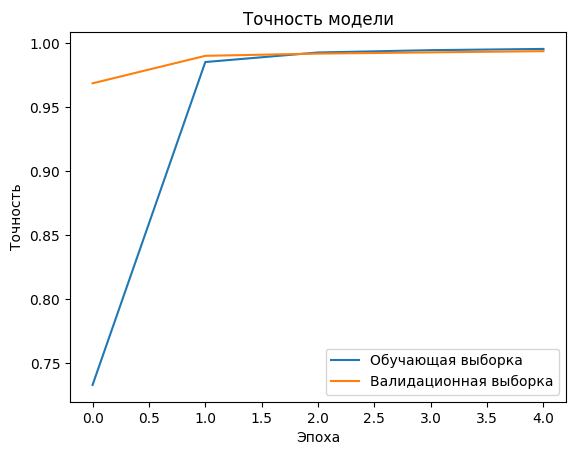

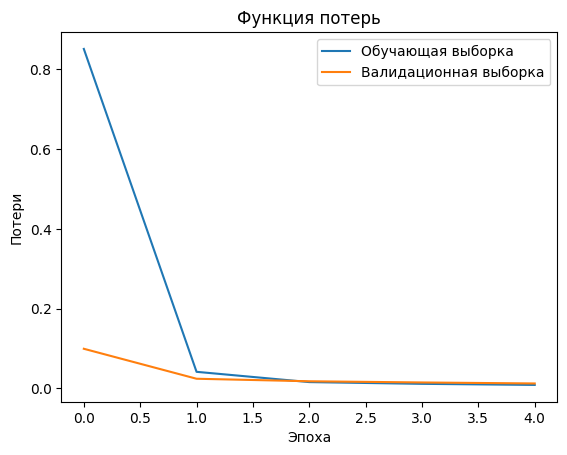

In [9]:
def show_training_plots(train_history):
    """Строит графики точности и функции потерь."""
    metrics = train_history.history

    plt.figure()
    plt.plot(metrics['accuracy'])
    plt.plot(metrics['val_accuracy'])
    plt.title('Точность модели')
    plt.xlabel('Эпоха')
    plt.ylabel('Точность')
    plt.legend(['Обучающая выборка', 'Валидационная выборка'])
    plt.show()

    plt.figure()
    plt.plot(metrics['loss'])
    plt.plot(metrics['val_loss'])
    plt.title('Функция потерь')
    plt.xlabel('Эпоха')
    plt.ylabel('Потери')
    plt.legend(['Обучающая выборка', 'Валидационная выборка'])
    plt.show()


show_training_plots(history)
